In [ ]:
print("hello")

hello


In [2]:
from modules.viz import MultiExperiment, metric_x_point, devplot
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
tcga = {
    'brca': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-20_04h40m53s_benchmark_1_classif_tcga_BRCA',
            'output/2026-01-20_04h41m15s_benchmark_1_classif_tcga_BRCA',
            'output/2026-01-20_04h55m44s_benchmark_1_classif_tcga_BRCA'
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    'gbm': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-20_04h49m16s_benchmark_1_classif_tcga_GBM',
            'output/2026-01-20_05h23m31s_benchmark_1_classif_tcga_GBM',
            'output/2026-01-20_05h30m09s_benchmark_1_classif_tcga_GBM',
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_nbreconstr_tcga',
        overwrite=True
    ),

    'lgg': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-20_04h51m55s_benchmark_1_classif_tcga_LGG',
            'output/2026-01-20_05h38m28s_benchmark_1_classif_tcga_LGG',
            'output/2026-01-20_05h42m38s_benchmark_1_classif_tcga_LGG',
            
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_classif_tcga',
        overwrite=True
    ),

    'cortex': MultiExperiment(
        experiment_dirs=[
            'output/2026-01-20_12h28m48s_benchmark_1b_classif_scvi_cortex',
            
        ],
        keys=[],
        out_dir='./experiments/benchmark_1_classif_tcga',
        overwrite=True
    ),

    # 'pbmc': MultiExperiment(
    #     experiment_dirs=[
    #         'output/2026-01-20_12h47m29s_benchmark_1b_classif_scvi_pbmc_dataset',
    #     ],
    #     keys=[],
    #     out_dir='./experiments/benchmark_1_classif_tcga',
    #     overwrite=True
    # ),
}

for k,v in tcga.items():
    v.test['dataset'] = k

In [4]:
test = pd.concat([tcga[k].test for k in tcga.keys()], ignore_index=True)
test

,config,trial,metric,value,dataset
0,gene-linear,0,loss,2.153064,brca
1,gene-linear,0,accuracy,0.600000,brca
2,gene-linear,0,precision,0.451401,brca
3,gene-linear,0,recall,0.517120,brca
4,gene-linear,0,f1,0.464552,brca
...,...,...,...,...,...
4180,pathway-vae,4,f1,0.854289,cortex
4181,pathway-vae,4,auroc,0.974528,cortex
4182,pathway-vae,4,time,133.681646,cortex
4183,pathway-vae,4,num_epochs,122.000000,cortex


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
test[test['metric']=='mae']

,config,trial,metric,value,dataset


In [7]:
# sns.catplot(
#     data=test[test['metric']=='accuracy'],
#     x='dataset',
#     y='value',
#     hue='config',
#     kind='box',
#     height=7,
#     aspect=12/7,
# )

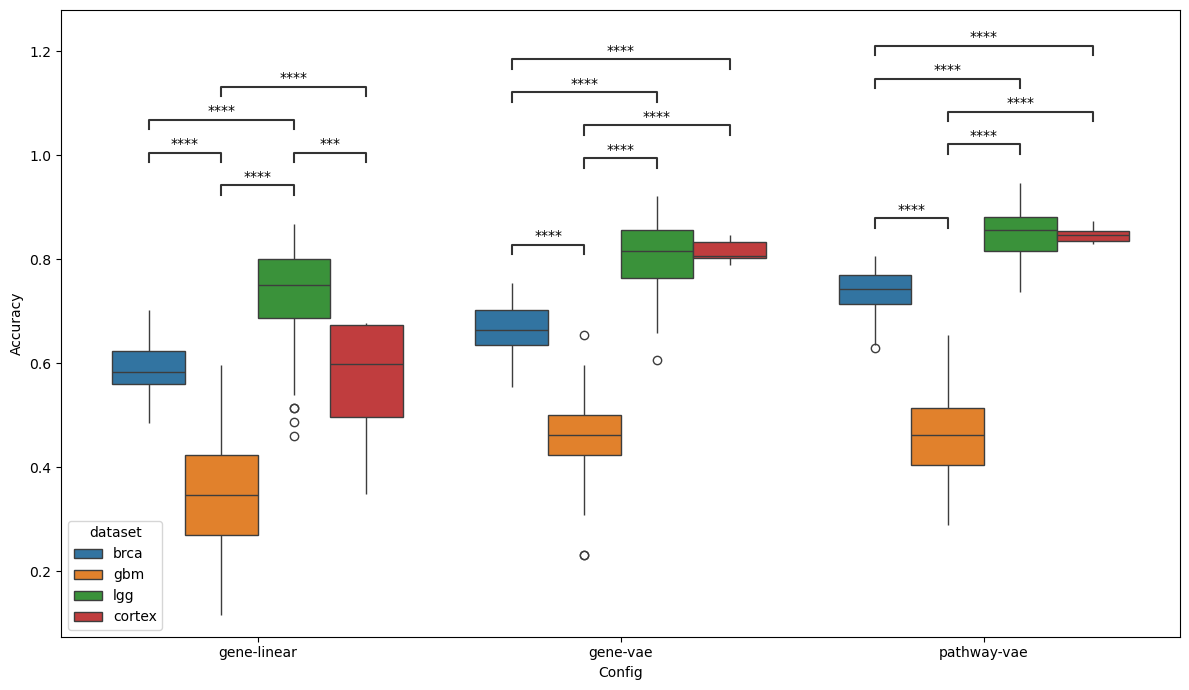

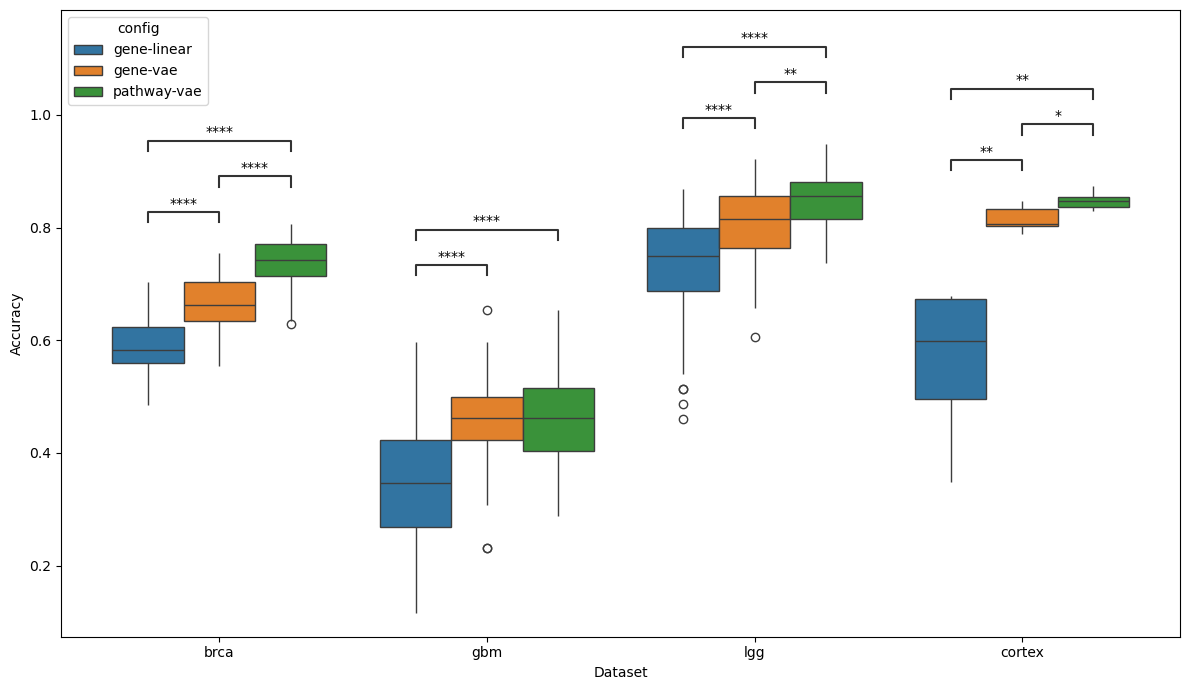

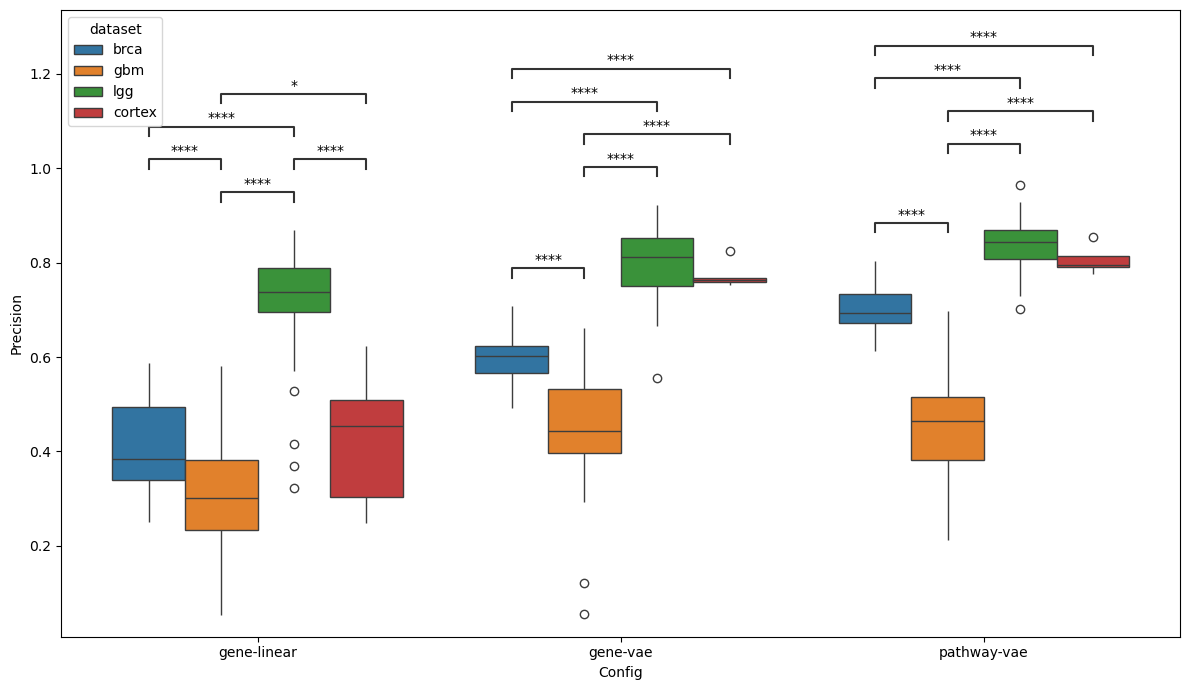

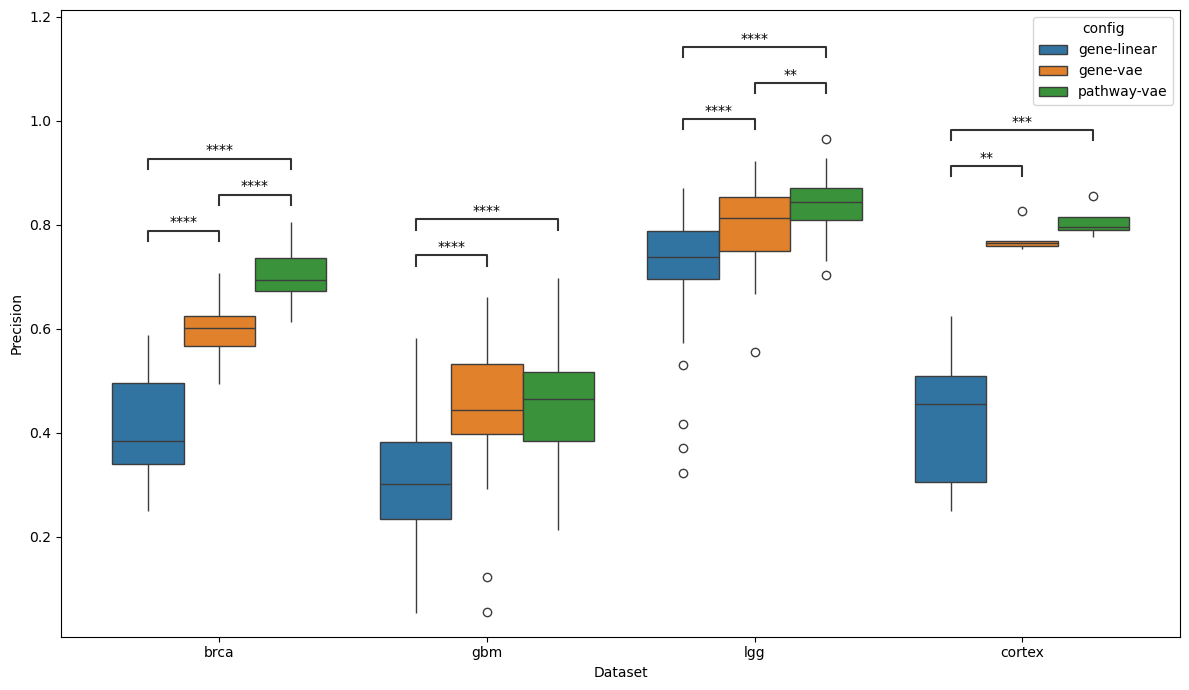

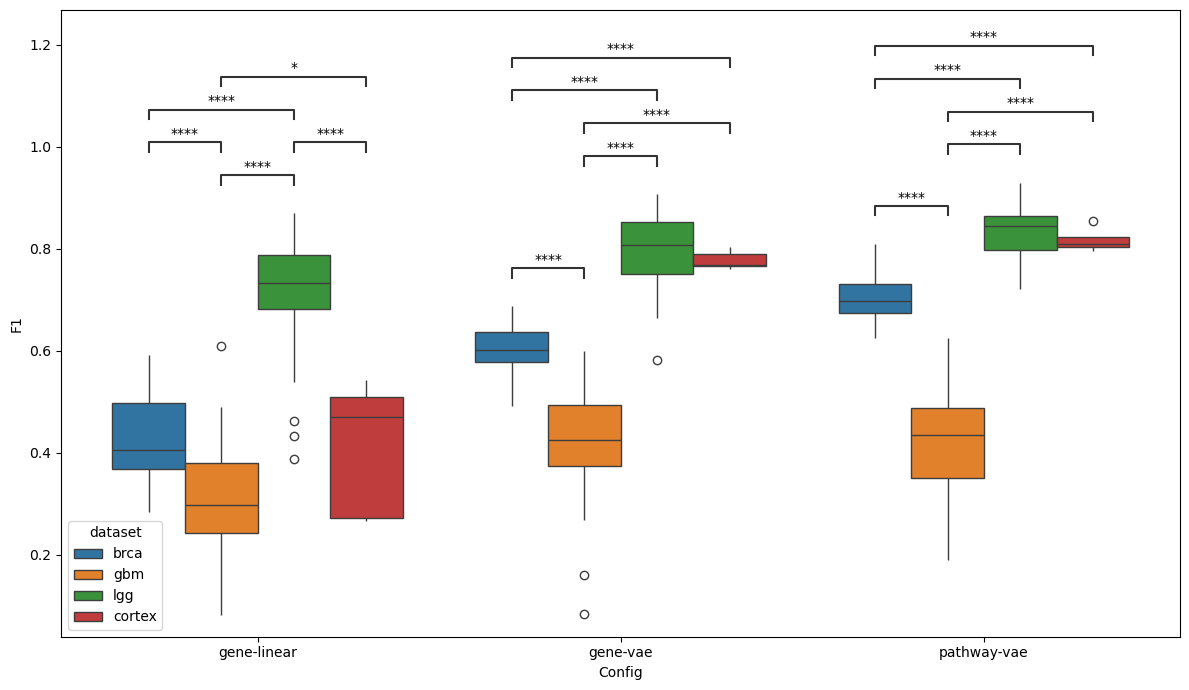

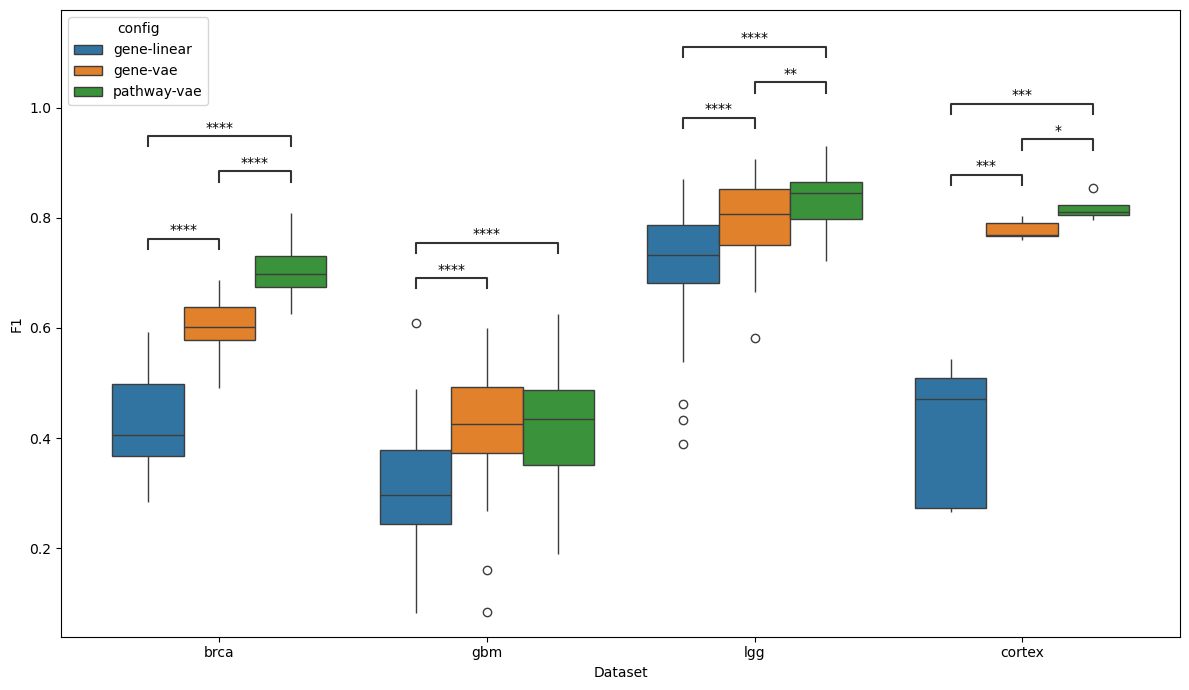

In [8]:
metric_x_point(
    df=test,
    cols=['config', 'dataset'],
    metrics=['accuracy', 'precision', 'f1'],
    figsize=(12,7),
    # strip=True,
    box=True,
    sig='within',
    hue=True,
    dodge=True,
)